In [9]:
# Imports, globals, style
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re
import warnings

from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")

# Using default matplotlib style (no scienceplots)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['figure.dpi'] = 100

# Experiment path (relative path)
GLOBAL_PATH = Path("results/testing")

OBSERVED = GLOBAL_PATH.name
FIG_DIR = Path("figure") / OBSERVED
FIG_DIR.mkdir(parents=True, exist_ok=True)

SHOW_STD_DEVIATION = False
GLOBAL_OPTIMA = -1

# Hatching patterns for bar plots
HATCHING_PATTERNS = ['///', '\\\\\\', 'xxx', 'ooo', '---']

# Best Known Solution (BKS) options to show the BKS line on convergence  
SHOW_BKS_LINE = False # True or False

# set the BKS value (needed if SHOW_BKS_LINE is True)
BKS_VALUE = 538
# Optional: override BKS per cluster
BKS_BY_CLUSTER = {}

# Log-scale option for convergence
LOG_SCALE_MEAN_DISTANCE = False # True or False

# Option to add Inset zoom near BKS (distance convergence)
SHOW_BKS_INSET_BEST = False
SHOW_BKS_INSET_MEAN = False

# Inset placement + sizing
BKS_INSET_W, BKS_INSET_H = "42%", "42%"
BKS_INSET_LOC = "upper right"
BKS_INSET_BORDERPAD = 1.0

# ===== FIXED inset limits =====
INSET_XLIM = (0, 200)
INSET_YLIM = (530, 600)
INSET_XTICKS = [0, 100, 200]
INSET_YTICKS_BASE = [600, 565, 530]

In [10]:
# Helper functions
def prettify_label(label: str) -> str:
    """Converts metric names to Indonesian labels"""
    label_map = {
        "route_time": "Waktu Rute (s)",
        "solving_time": "Waktu Penyelesaian (s)",
        "distance": "Jarak",
        "cost": "Biaya",
        "best": "Terbaik",
        "mean": "Rata-rata",
    }

    label_lower = label.lower().replace("_", " ").strip()
    for key, value in label_map.items():
        if key in label_lower:
            return value

    return label.replace("_", " ").title()


def print_numeric_table(title: str, df: pd.DataFrame, digits: int = 3):
    print(f"\n=== {title} ===")

    if df is None or df.empty:
        print("(tidak ada data)")
        return

    out = df.copy()

    for col in out.columns:
        if pd.api.types.is_numeric_dtype(out[col]):
            out[col] = out[col].map(
                lambda x: f"{x:.{digits}f}" if pd.notna(x) else "-"
            )

    print(out.to_string(index=False))

PRINT_BEST_PER_ITER = True
SAVE_BEST_PER_ITER_CSV = True


def print_best_per_iter_table(
    cluster_name: str,
    convergence_data: dict,
    metric: str = "best",
    table_name: str = "Jarak Best per Iterasi",
    digits: int = 3,
):
    rows = []

    all_iters = set()
    for algo_name, algo_data in convergence_data.items():
        if metric not in algo_data:
            continue

        iterations, mean_vals, std_vals = algo_data[metric]
        all_iters.update(iterations.astype(int).tolist())

    all_iters = sorted(all_iters)

    if not all_iters:
        print(f"\n=== {table_name} ({cluster_name}) ===")
        print("(tidak ada data)")
        return

    lookup = {}
    for algo_name, algo_data in convergence_data.items():
        if metric not in algo_data:
            continue

        iterations, mean_vals, std_vals = algo_data[metric]
        lookup[algo_name] = {
            int(it): float(val)
            for it, val in zip(iterations, mean_vals)
        }

    for it in all_iters:
        row = {"Iterasi": it}

        for algo_name in sorted(lookup.keys()):
            row[algo_name] = lookup[algo_name].get(it, np.nan)

        rows.append(row)

    df_iter = pd.DataFrame(rows)

    print(f"\n=== {table_name} ({cluster_name}) ===")

    out = df_iter.copy()
    for col in out.columns:
        if col != "Iterasi" and pd.api.types.is_numeric_dtype(out[col]):
            out[col] = out[col].map(
                lambda x: f"{x:.{digits}f}" if pd.notna(x) else "-"
            )

    with pd.option_context(
        "display.max_rows", None,
        "display.max_columns", None,
        "display.width", None,
    ):
        print(out.to_string(index=False))

    if SAVE_BEST_PER_ITER_CSV:
        save_path = FIG_DIR / f"table_{cluster_name}_{metric}_per_iter.csv"
        df_iter.to_csv(save_path, index=False)
        print(f"Saved table to: {save_path}")
        

In [11]:
# Analyze Convergence Code
class ConvergenceAnalyzer:
    """
    Loads metrics per algorithm per run per cluster.

    Expected structure:
      results/.../<algo>_run1/cluster_0/metrics.csv
      results/.../<algo>_run1/cluster_1/metrics.csv

    Fallback:
      results/.../<algo>_run1/metrics.csv -> treated as cluster_0
    """
    def __init__(self, parent_dir: str):
        self.parent_dir = Path(parent_dir)
        self.data = {}

    def _cluster_sort_key(self, name: str):
        m = re.search(r"cluster_(\d+)", name)
        return int(m.group(1)) if m else 10**9

    def list_clusters(self):
        return sorted(self.data.keys(), key=self._cluster_sort_key)

    def _sanitize_metrics_df(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()

        def make_iter_1_based(n: int) -> np.ndarray:
            return np.arange(1, n + 1, dtype=int)

        if "iter" not in df.columns:
            df.insert(0, "iter", make_iter_1_based(len(df)))
            return df

        df["iter"] = pd.to_numeric(df["iter"], errors="coerce")

        if df["iter"].isna().all():
            df["iter"] = make_iter_1_based(len(df))
            return df

        df["iter"] = df["iter"].ffill().bfill()

        if df["iter"].nunique(dropna=True) <= 1:
            df["iter"] = make_iter_1_based(len(df))
            return df

        df = df.sort_values("iter")
        df = df.drop_duplicates(subset=["iter"], keep="last").reset_index(drop=True)

        first_iter = df["iter"].iloc[0]
        df["iter"] = (df["iter"] - first_iter + 1).astype(int)

        if (not df["iter"].is_monotonic_increasing) or df["iter"].duplicated().any():
            df["iter"] = make_iter_1_based(len(df))

        return df

    def load_data(self):
        print(f"Looking for data in: {self.parent_dir}")
        if not self.parent_dir.exists():
            print(f"ERROR: Directory {self.parent_dir} does not exist!")
            return

        run_pattern = re.compile(r"^(.+?)_run(\d+)$")
        subdirs = list(self.parent_dir.iterdir())
        print(f"Found {len(subdirs)} items in directory")

        loaded_files = 0

        for run_dir in subdirs:
            if not run_dir.is_dir():
                continue

            match = run_pattern.match(run_dir.name)
            if not match:
                continue

            algo_name = match.group(1)
            print(f"  Processing: {run_dir.name} -> Algorithm: {algo_name}")

            cluster_dirs = [
                d for d in run_dir.iterdir()
                if d.is_dir() and d.name.startswith("cluster_")
            ]
            cluster_dirs = sorted(cluster_dirs, key=lambda d: self._cluster_sort_key(d.name))

            if cluster_dirs:
                for cdir in cluster_dirs:
                    metrics_file = cdir / "metrics.csv"
                    if not metrics_file.exists():
                        continue

                    df = pd.read_csv(metrics_file)
                    df = self._sanitize_metrics_df(df)

                    cluster_name = cdir.name
                    self.data.setdefault(cluster_name, {})
                    self.data[cluster_name].setdefault(algo_name, [])
                    self.data[cluster_name][algo_name].append(df)

                    loaded_files += 1
                    print(f"    Loaded {len(df)} rows from {cluster_name}")
            else:
                metrics_file = run_dir / "metrics.csv"
                if not metrics_file.exists():
                    print("    WARNING: no cluster_* folders and no metrics.csv in run root")
                    continue

                df = pd.read_csv(metrics_file)
                df = self._sanitize_metrics_df(df)

                cluster_name = "cluster_0"
                self.data.setdefault(cluster_name, {})
                self.data[cluster_name].setdefault(algo_name, [])
                self.data[cluster_name][algo_name].append(df)

                loaded_files += 1
                print(f"    Loaded {len(df)} rows from {cluster_name} (root metrics.csv)")

        print("\n=== Load Summary ===")
        print(f"Total metrics files loaded: {loaded_files}")
        print(f"Total clusters loaded: {len(self.data)}")
        for cluster in self.list_clusters():
            algos = self.data[cluster]
            print(f"  {cluster}: {len(algos)} algorithms")
            for algo, runs in algos.items():
                print(f"    - {algo}: {len(runs)} runs")

In [12]:
def get_convergence_data(analyzer: ConvergenceAnalyzer, cluster_name: str):
    """
    Returns:
      results[algo_name][metric] = (iters, mean_values, std_values)
    """
    results = {}
    cluster_data = analyzer.data.get(cluster_name, {})

    for algo_name, runs in cluster_data.items():
        if not runs:
            continue

        algo_results = {}
        metrics_to_collect = ["best", "mean", "best_route_time", "mean_route_time"]

        for metric in metrics_to_collect:
            all_iterations = []
            all_values = []

            for df in runs:
                if metric in df.columns and "iter" in df.columns:
                    all_iterations.append(df["iter"].values.astype(float))
                    all_values.append(df[metric].values.astype(float))

            if not all_iterations:
                continue

            min_iter = min([iters[0] for iters in all_iterations])
            max_iter = max([iters[-1] for iters in all_iterations])
            common_iters = np.arange(min_iter, max_iter + 1)

            interpolated_values = []
            for iters, vals in zip(all_iterations, all_values):
                if len(iters) > 1:
                    interp_vals = np.interp(common_iters, iters, vals)
                else:
                    interp_vals = np.full_like(common_iters, float(vals[0]), dtype=float)

                interpolated_values.append(interp_vals)

            mean_values = np.mean(interpolated_values, axis=0)
            std_values = np.std(interpolated_values, axis=0)

            algo_results[metric] = (common_iters, mean_values, std_values)

        if algo_results:
            results[algo_name] = algo_results

    print(f"\nConvergence data prepared for cluster={cluster_name}: {len(results)} algorithms")
    for algo, metrics in results.items():
        print(f"  {algo}: {list(metrics.keys())}")

    return results


def plot_convergence_for_cluster(cluster_name: str, convergence_data: dict):
    if not convergence_data:
        print(f"No convergence data for {cluster_name}")
        return

    metric_groups = {
        "distance": ["best", "mean"],
        "time": ["best_route_time", "mean_route_time"],
    }

    prop_cycle = plt.rcParams['axes.prop_cycle']
    colors = prop_cycle.by_key()['color']

    markers = ['o', 's', '^', 'v', 'D', 'p', '*', 'h', '<', '>']

    metric_labels_id = {
        "distance": "jarak",
        "time": "waktu",
    }

    bks = BKS_BY_CLUSTER.get(cluster_name, BKS_VALUE)
    if bks is not None:
        try:
            bks = float(bks)
        except Exception:
            bks = None

    def _apply_clean_log_ticks(ax, bks_val=None):
        ax.set_yscale('log')

        ymin, ymax = ax.get_ylim()
        if (not np.isfinite(ymin)) or (not np.isfinite(ymax)) or ymin <= 0 or ymax <= 0:
            return

        pmin = int(np.floor(np.log10(ymin)))
        pmax = int(np.ceil(np.log10(ymax)))
        decade_ticks = [10.0 ** p for p in range(pmin, pmax + 1)]

        ticks = list(decade_ticks)
        if (
            bks_val is not None
            and np.isfinite(bks_val)
            and bks_val > 0
            and ymin <= bks_val <= ymax
        ):
            ticks.append(float(bks_val))

        ticks = sorted(set(ticks))
        ax.set_yticks(ticks)

        def fmt(y, _pos):
            if bks_val is not None and np.isfinite(bks_val) and bks_val > 0:
                if abs(np.log10(y / bks_val)) < 1e-6:
                    return "BKS"

            if y > 0:
                exp = int(round(np.log10(y)))
                if np.isclose(y, 10.0 ** exp, rtol=0, atol=1e-12):
                    return rf"$10^{{{exp}}}$"

            return ""

        ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt))
        ax.yaxis.set_minor_locator(mticker.NullLocator())

    def _add_fixed_inset(ax, sub_metric: str, metric_group: str):
        if not (metric_group == "distance" and sub_metric in ["best", "mean"]):
            return

        x0, x1 = INSET_XLIM
        y0, y1 = INSET_YLIM

        axins = inset_axes(
            ax,
            width=BKS_INSET_W,
            height=BKS_INSET_H,
            loc=BKS_INSET_LOC,
            borderpad=BKS_INSET_BORDERPAD,
        )

        for algo_idx, (algo_name, algo_data) in enumerate(convergence_data.items()):
            if sub_metric not in algo_data:
                continue

            iters, vals, _std = algo_data[sub_metric]
            iters = np.asarray(iters, dtype=float)
            vals = np.asarray(vals, dtype=float)

            m = np.isfinite(iters) & np.isfinite(vals)
            iters = iters[m]
            vals = vals[m]

            if len(iters) < 2:
                continue

            mw = (iters >= x0) & (iters <= x1)
            if np.sum(mw) < 2:
                continue

            it_w = iters[mw]
            v_w = vals[mw]

            color = colors[algo_idx % len(colors)]
            marker = markers[algo_idx % len(markers)]
            markevery = max(1, len(it_w) // 8)

            axins.plot(
                it_w,
                v_w,
                color=color,
                linewidth=1.9,
                linestyle='-',
                marker=marker,
                markevery=markevery,
                markersize=3,
                markeredgewidth=1.0,
                markerfacecolor='white',
                markeredgecolor=color,
                alpha=0.95,
            )

        if SHOW_BKS_LINE and bks is not None:
            axins.axhline(
                y=bks,
                color="red",
                linestyle="--",
                linewidth=1.8,
                alpha=0.9,
            )

        axins.set_xlim(x0, x1)
        axins.set_ylim(y0, y1)

        axins.set_xticks(INSET_XTICKS)

        yticks = list(INSET_YTICKS_BASE)
        if bks is not None and y0 <= bks <= y1 and bks not in yticks:
            yticks.append(float(bks))

        yticks = sorted(set(yticks))
        axins.set_yticks(yticks)

        def yfmt(y, _pos):
            if bks is not None and np.isfinite(bks) and abs(y - bks) < 1e-6:
                return "BKS"
            return f"{int(round(y))}"

        axins.yaxis.set_major_formatter(mticker.FuncFormatter(yfmt))
        axins.yaxis.set_minor_locator(mticker.NullLocator())

        axins.grid(True, alpha=0.25, linestyle="--")
        axins.tick_params(labelsize=8)

        mark_inset(
            ax,
            axins,
            loc1=2,
            loc2=4,
            fc="none",
            ec="0.3",
            linewidth=1.0,
        )

    for metric_group, metrics_list in metric_groups.items():
        available_metrics = []

        for sub_metric in metrics_list:
            for algo_data in convergence_data.values():
                if sub_metric in algo_data:
                    available_metrics.append(sub_metric)
                    break

        if not available_metrics:
            continue

        fig, axes = plt.subplots(
            1,
            len(available_metrics),
            figsize=(5 * len(available_metrics), 4),
            sharex=True,
            sharey=False,
        )

        if len(available_metrics) == 1:
            axes = [axes]

        handles, labels = [], []

        for idx, sub_metric in enumerate(available_metrics):
            ax = axes[idx]

            if metric_group == "distance" and GLOBAL_OPTIMA != -1:
                ax.axhline(
                    y=GLOBAL_OPTIMA,
                    color="red",
                    linestyle=":",
                    linewidth=1.5,
                    alpha=0.7,
                    label="_nolegend_",
                )

            if (
                metric_group == "distance"
                and sub_metric in ["best", "mean"]
                and bks is not None
                and SHOW_BKS_LINE
            ):
                ax.axhline(
                    y=bks,
                    color="red",
                    linestyle="--",
                    linewidth=2.2,
                    alpha=0.9,
                    label="_nolegend_",
                )

            for algo_idx, (algo_name, algo_data) in enumerate(convergence_data.items()):
                if sub_metric not in algo_data:
                    continue

                iterations, mean_vals, std_vals = algo_data[sub_metric]

                color = colors[algo_idx % len(colors)]
                marker = markers[algo_idx % len(markers)]
                markevery = max(1, len(iterations) // 15)

                line, = ax.plot(
                    iterations,
                    mean_vals,
                    label=algo_name,
                    color=color,
                    linewidth=2.5,
                    linestyle='-',
                    marker=marker,
                    markevery=markevery,
                    markersize=4,
                    markeredgewidth=1.2,
                    markerfacecolor='white',
                    markeredgecolor=color,
                    alpha=0.9,
                )

                if idx == 0:
                    handles.append(line)
                    labels.append(algo_name)

                if SHOW_STD_DEVIATION and len(std_vals) > 0 and np.any(std_vals > 0):
                    ax.fill_between(
                        iterations,
                        mean_vals - std_vals,
                        mean_vals + std_vals,
                        color=color,
                        alpha=0.15,
                    )

            if (
                metric_group == "distance"
                and sub_metric == "mean"
                and LOG_SCALE_MEAN_DISTANCE
            ):
                _apply_clean_log_ticks(ax, bks_val=bks)

            if (
                metric_group == "distance"
                and sub_metric == "best"
                and SHOW_BKS_INSET_BEST
            ):
                _add_fixed_inset(ax, sub_metric="best", metric_group=metric_group)

            if (
                metric_group == "distance"
                and sub_metric == "mean"
                and SHOW_BKS_INSET_MEAN
            ):
                _add_fixed_inset(ax, sub_metric="mean", metric_group=metric_group)

            title_map = {
                "best": "Konvergensi Solusi Terbaik",
                "mean": "Konvergensi Solusi Rata-rata",
                "best_route_time": "Konvergensi Waktu Rute Terbaik",
                "mean_route_time": "Konvergensi Waktu Rute Rata-rata",
            }

            ylabel_map = {
                "best": "Jarak",
                "mean": "Jarak",
                "best_route_time": "Waktu Rute (s)",
                "mean_route_time": "Waktu Rute (s)",
            }

            ax.set_title(
                title_map.get(sub_metric, sub_metric),
                fontweight="bold",
                fontsize=11,
            )
            ax.grid(True, alpha=0.3, linestyle="--")
            ax.set_ylabel(
                ylabel_map.get(sub_metric, sub_metric),
                fontweight="bold",
                fontsize=10,
            )

        fig.supxlabel("Iterasi", fontweight="bold", fontsize=11)

        if labels:
            fig.legend(
                handles,
                labels,
                loc="upper center",
                bbox_to_anchor=(0.5, 0.95),
                ncol=len(labels),
                frameon=True,
                fontsize=9,
                columnspacing=1.0,
                handletextpad=0.6,
            )

        fig.suptitle(
            f"Konvergensi ({cluster_name})",
            fontweight="bold",
            y=0.85,
            fontsize=12,
        )

        plt.tight_layout(rect=[0, 0, 1, 0.88])

        conv_rows = []

        for algo_name, algo_data in convergence_data.items():
            row = {"Algoritma": algo_name}

            for sub_metric in available_metrics:
                if sub_metric not in algo_data:
                    continue

         
                iterations, mean_vals, std_vals = algo_data[sub_metric]

                awal = float(mean_vals[0])
                akhir = float(mean_vals[-1])

                row[f"{sub_metric}_iter_akhir"] = float(iterations[-1])
                row[f"{sub_metric}_nilai_awal"] = awal
                row[f"{sub_metric}_nilai_akhir"] = akhir
                row[f"{sub_metric}_std_akhir"] = float(std_vals[-1]) if len(std_vals) > 0 else np.nan
                row[f"{sub_metric}_nilai_terbaik"] = float(np.min(mean_vals))
                row[f"{sub_metric}_improvement"] = awal - akhir
                row[f"{sub_metric}_improvement_%"] = ((awal - akhir) / awal) * 100 if awal != 0 else np.nan

            conv_rows.append(row)

        df_conv = pd.DataFrame(conv_rows)

        print_numeric_table(
            f"Tabel Konvergensi {cluster_name} - {metric_labels_id[metric_group]}",
            df_conv,
            digits=3,
        )
        
        if PRINT_BEST_PER_ITER and metric_group == "distance" and "best" in available_metrics:
            print_best_per_iter_table(
                cluster_name=cluster_name,
                convergence_data=convergence_data,
                metric="best",
                table_name="Tabel Best Jarak per Iterasi",
                digits=3,
            )
        

        save_path = FIG_DIR / f"convergence_{cluster_name}_{metric_labels_id[metric_group]}.png"
        plt.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved to: {save_path}")
        plt.show()

In [13]:
def get_final_metric_summary(analyzer: ConvergenceAnalyzer, metric: str = "best"):
    """
    summary[cluster_name][algo_name] = (mean_final, std_final, n_runs)
    final = last row value of metric for each run.
    """
    summary = {}

    for cluster_name, algos in analyzer.data.items():
        summary.setdefault(cluster_name, {})

        for algo_name, runs in algos.items():
            finals = []

            for df in runs:
                if metric in df.columns and len(df) > 0:
                    finals.append(float(df[metric].iloc[-1]))

            if finals:
                summary[cluster_name][algo_name] = (
                    float(np.mean(finals)),
                    float(np.std(finals)),
                    int(len(finals)),
                )

    return summary


def plot_distance_comparison_per_cluster(analyzer: ConvergenceAnalyzer, metric: str = "best"):
    summary = get_final_metric_summary(analyzer, metric=metric)

    if not summary:
        print("No per-cluster summary data available.")
        return

    clusters = analyzer.list_clusters()
    all_algos = sorted({algo for c in summary.values() for algo in c.keys()})

    if not all_algos:
        print("No algorithms found for per-cluster comparison.")
        return

    metric_id = "terbaik" if metric == "best" else "rata-rata"

    table_rows = []

    for cluster in clusters:
        m_cluster = re.search(r"cluster_(\d+)", cluster)
        cluster_label = m_cluster.group(1) if m_cluster else cluster

        cluster_rows = []
        cluster_vals = []

        for algo in all_algos:
            if cluster in summary and algo in summary[cluster]:
                mean_val, std_val, n_runs = summary[cluster][algo]
            else:
                mean_val, std_val, n_runs = np.nan, np.nan, 0

            if np.isfinite(mean_val):
                cluster_vals.append(mean_val)

            cluster_rows.append({
                "Klaster": cluster_label,
                "Algoritma": algo,
                "Jarak Akhir Mean": mean_val,
                "Std": std_val,
                "n": n_runs,
            })

        best_val = min(cluster_vals) if cluster_vals else np.nan

        for row in cluster_rows:
            val = row["Jarak Akhir Mean"]

            if np.isfinite(val) and np.isfinite(best_val):
                row["Selisih dari Terbaik"] = val - best_val
                row["Selisih (%)"] = ((val - best_val) / best_val) * 100 if best_val != 0 else np.nan
            else:
                row["Selisih dari Terbaik"] = np.nan
                row["Selisih (%)"] = np.nan

            table_rows.append(row)

    df_table = pd.DataFrame(table_rows)

    print_numeric_table(
        f"Tabel Perbandingan Jarak per Klaster ({metric_id} akhir)",
        df_table,
        digits=3,
    )

    # ===== ORIGINAL PLOT =====
    x = np.arange(len(clusters), dtype=float)
    n_algos = len(all_algos)
    group_width = 0.8
    bar_w = group_width / max(n_algos, 1)

    fig, ax = plt.subplots(figsize=(max(7, 1.3 * len(clusters)), 4))

    prop_cycle = plt.rcParams['axes.prop_cycle']
    colors = prop_cycle.by_key()['color']

    for j, algo in enumerate(all_algos):
        means, stds = [], []

        for cluster in clusters:
            if cluster in summary and algo in summary[cluster]:
                m, s, _n = summary[cluster][algo]
            else:
                m, s = np.nan, np.nan

            means.append(m)
            stds.append(s)

        means = np.array(means, dtype=float)
        stds = np.array(stds, dtype=float)

        offsets = x - (group_width / 2) + (j + 0.5) * bar_w
        hatch_pattern = HATCHING_PATTERNS[j % len(HATCHING_PATTERNS)]

        ax.bar(
            offsets,
            means,
            width=bar_w,
            yerr=stds,
            capsize=4,
            label=algo,
            color=colors[j % len(colors)],
            alpha=0.75,
            hatch=hatch_pattern,
            edgecolor='black',
            linewidth=1.0,
        )

    cluster_nums = []

    for c in clusters:
        m = re.search(r"cluster_(\d+)", c)
        cluster_nums.append(m.group(1) if m else c)

    ax.set_xticks(x)
    ax.set_xticklabels(cluster_nums, fontsize=10)
    ax.set_xlabel("Klaster", fontweight="bold", fontsize=11)
    ax.set_ylabel("Jarak Akhir", fontweight="bold", fontsize=11)

    ax.set_title(
        f"Perbandingan Jarak per Klaster ({metric_id} akhir)",
        fontweight="bold",
        pad=15,
        fontsize=12,
    )

    ax.grid(True, alpha=0.3, axis="y", linestyle="--")

    ncol = len(all_algos)
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 1.3),
        ncol=ncol,
        frameon=True,
        fontsize=9,
        columnspacing=1.0,
    )

    plt.tight_layout()

    save_path = FIG_DIR / f"perbandingan_jarak_per_klaster_{metric}.png"
    plt.savefig(save_path, bbox_inches="tight", dpi=150)
    print(f"Saved to: {save_path}")
    plt.show()


def plot_summary_boxplots():
    summary_path = GLOBAL_PATH / "experiment_summary.csv"

    if not summary_path.exists():
        print("experiment_summary.csv not found, skipping summary boxplots.")
        return

    df = pd.read_csv(summary_path)
    algorithms = sorted(df["algorithm"].unique())

    print(f"Loaded {len(df)} rows from {summary_path}")
    print(f"Algorithms: {algorithms}")

    metric_names_id = {
        "solving_time": "Waktu Penyelesaian",
        "route_time": "Waktu Rute",
        "distance": "Jarak",
        "cost": "Biaya",
    }

    def _metric_stats(metric: str) -> pd.DataFrame:
        rows = []

        for algo in algorithms:
            values = pd.to_numeric(
                df[df["algorithm"] == algo][metric],
                errors="coerce",
            ).dropna().values

            if len(values) == 0:
                continue

            rows.append({
                "Metrik": metric_names_id.get(metric, metric),
                "Algoritma": algo,
                "n": len(values),
                "Mean": float(np.mean(values)),
                "Std": float(np.std(values)),
                "Min": float(np.min(values)),
                "Median": float(np.median(values)),
                "Max": float(np.max(values)),
            })

        return pd.DataFrame(rows)

    def _draw_boxplot_on_axis(ax, metric: str, show_xlabel: bool = False):
        box_data, algo_labels = [], []

        for algo in algorithms:
            values = pd.to_numeric(
                df[df["algorithm"] == algo][metric],
                errors="coerce",
            ).dropna().values

            if len(values) > 0:
                box_data.append(values)
                algo_labels.append(algo)

        if not box_data:
            return False

        positions = np.arange(1, len(box_data) + 1) * 0.9

        bp = ax.boxplot(
            box_data,
            patch_artist=True,
            showmeans=False,
            showfliers=False,
            widths=0.5,
            positions=positions,
        )

        colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

        for i, patch in enumerate(bp["boxes"]):
            patch.set_facecolor(colors[i % len(colors)])
            patch.set_alpha(0.7)
            patch.set_edgecolor("black")
            patch.set_linewidth(1.2)

        for data, pos in zip(box_data, positions):
            mean_val = np.mean(data)
            y_min, y_max = ax.get_ylim()
            offset = 0.02 * (y_max - y_min)

            ax.text(
                pos,
                mean_val + offset,
                f"{mean_val:.2f}",
                ha="center",
                va="bottom",
                fontsize=8,
                fontweight="bold",
            )

        if show_xlabel:
            ax.set_xlabel("Algoritma", fontweight="bold", fontsize=11)

        ax.set_ylabel(prettify_label(metric), fontweight="bold", fontsize=11)

        max_name_len = max(len(str(a)) for a in algo_labels)
        rotation = 45 if max_name_len > 8 else 0

        ax.set_xticks(positions)
        ax.set_xticklabels(
            algo_labels,
            rotation=rotation,
            ha="right" if rotation else "center",
            fontsize=9,
        )

        ax.grid(True, alpha=0.3, axis="y", linestyle="--")

        return True

    combined_metrics = [m for m in ["distance", "route_time"] if m in df.columns]

    if len(combined_metrics) == 2:
        combined_tables = []

        for metric in combined_metrics:
            stat_df = _metric_stats(metric)
            if not stat_df.empty:
                combined_tables.append(stat_df)

        if combined_tables:
            df_combined_table = pd.concat(combined_tables, ignore_index=True)

            print_numeric_table(
                "Tabel Statistik Jarak dan Waktu Rute",
                df_combined_table,
                digits=3,
            )

        fig, axes = plt.subplots(
            1,
            2,
            figsize=(12, 4),
            sharex=False,
            sharey=False,
        )

        _draw_boxplot_on_axis(axes[0], "distance", show_xlabel=False)
        _draw_boxplot_on_axis(axes[1], "route_time", show_xlabel=False)

        fig.supxlabel("Algoritma", fontweight="bold", fontsize=11)

        fig.suptitle(
            "Perbandingan Jarak dan Waktu Rute",
            fontweight="bold",
            fontsize=12,
            y=0.98,
        )

        plt.tight_layout(rect=[0, 0.03, 1, 0.92])

        save_path = FIG_DIR / "distance_route_time_boxplot.png"
        plt.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved to: {save_path}")
        plt.show()

    else:
        for metric in combined_metrics:
            df_table = _metric_stats(metric)

            print_numeric_table(
                f"Tabel Statistik {metric_names_id.get(metric, metric)}",
                df_table,
                digits=3,
            )

            fig, ax = plt.subplots(figsize=(6, 4))
            ok = _draw_boxplot_on_axis(ax, metric, show_xlabel=True)

            if not ok:
                plt.close(fig)
                continue

            ax.set_title(
                f"Perbandingan {metric_names_id.get(metric, metric)}",
                fontweight="bold",
                pad=20,
                fontsize=12,
            )

            plt.tight_layout()

            save_path = FIG_DIR / f"{metric}_boxplot.png"
            plt.savefig(save_path, bbox_inches="tight", dpi=150)
            print(f"Saved to: {save_path}")
            plt.show()

    remaining_metrics = [
        m for m in ["solving_time", "cost"]
        if m in df.columns
    ]

    for metric in remaining_metrics:
        df_table = _metric_stats(metric)

        print_numeric_table(
            f"Tabel Statistik {metric_names_id.get(metric, metric)}",
            df_table,
            digits=3,
        )

        fig, ax = plt.subplots(figsize=(6, 4))
        ok = _draw_boxplot_on_axis(ax, metric, show_xlabel=True)

        if not ok:
            plt.close(fig)
            continue

        ax.set_title(
            f"Perbandingan {metric_names_id.get(metric, metric)}",
            fontweight="bold",
            pad=20,
            fontsize=12,
        )

        plt.tight_layout()

        save_path = FIG_DIR / f"{metric}_boxplot.png"
        plt.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved to: {save_path}")
        plt.show()

Looking for data in: results/testing
Found 32 items in directory
  Processing: ntnsga2_run1 -> Algorithm: ntnsga2
    Loaded 23 rows from cluster_0
    Loaded 39 rows from cluster_1
    Loaded 40 rows from cluster_2
    Loaded 41 rows from cluster_3
    Loaded 42 rows from cluster_4
    Loaded 37 rows from cluster_5
    Loaded 33 rows from cluster_6
  Processing: ntnsga2_run19 -> Algorithm: ntnsga2
    Loaded 25 rows from cluster_0
    Loaded 39 rows from cluster_1
    Loaded 39 rows from cluster_2
    Loaded 40 rows from cluster_3
    Loaded 41 rows from cluster_4
    Loaded 37 rows from cluster_5
    Loaded 34 rows from cluster_6
  Processing: ntnsga2_run5 -> Algorithm: ntnsga2
    Loaded 26 rows from cluster_0
    Loaded 39 rows from cluster_1
    Loaded 40 rows from cluster_2
    Loaded 41 rows from cluster_3
    Loaded 37 rows from cluster_4
    Loaded 36 rows from cluster_5
    Loaded 30 rows from cluster_6
  Processing: ntnsga2_run18 -> Algorithm: ntnsga2
    Loaded 25 rows from

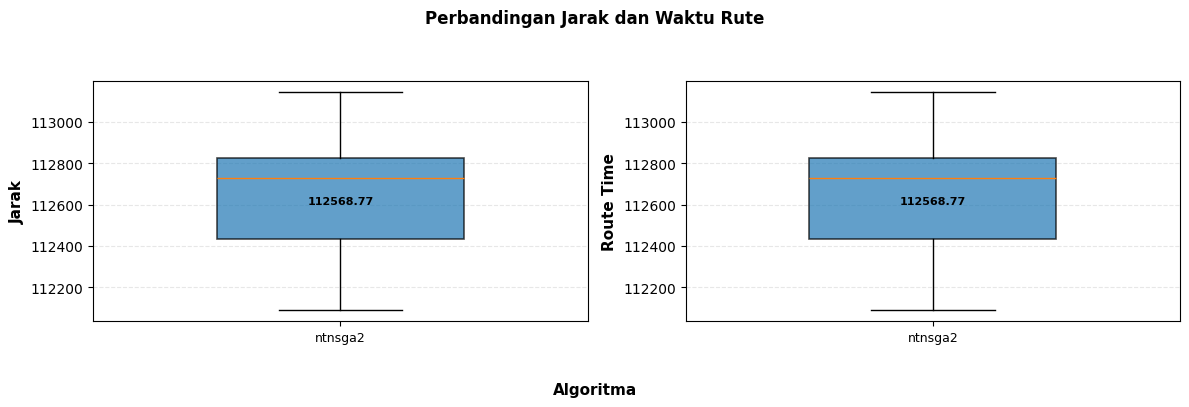


=== Tabel Statistik Waktu Penyelesaian ===
            Metrik Algoritma      n  Mean   Std   Min Median   Max
Waktu Penyelesaian   ntnsga2 30.000 2.844 0.013 2.820  2.841 2.889
Saved to: figure/testing/solving_time_boxplot.png


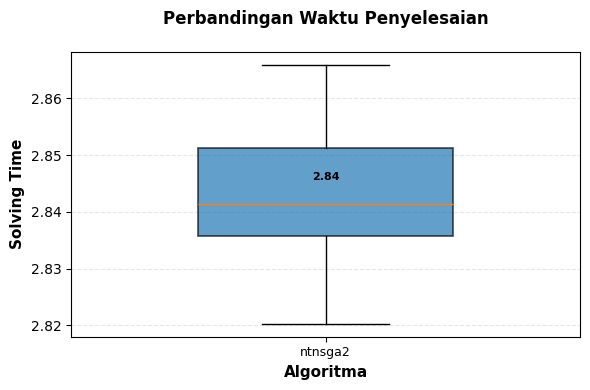


=== Tabel Statistik Biaya ===
Metrik Algoritma      n       Mean   Std        Min     Median        Max
 Biaya   ntnsga2 30.000 700000.000 0.000 700000.000 700000.000 700000.000
Saved to: figure/testing/cost_boxplot.png


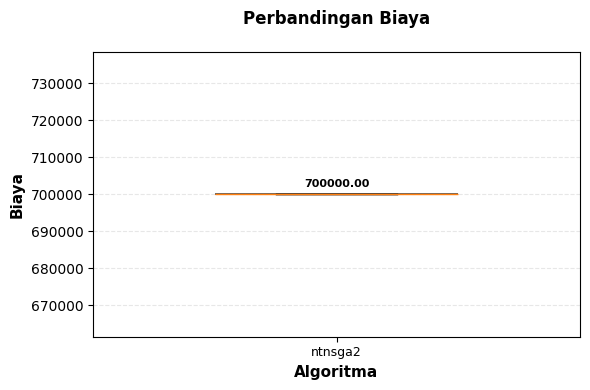

In [14]:
analyzer = ConvergenceAnalyzer(GLOBAL_PATH)
analyzer.load_data()

plot_summary_boxplots()


=== Tabel Perbandingan Jarak per Klaster (terbaik akhir) ===
Klaster Algoritma Jarak Akhir Mean     Std      n Selisih dari Terbaik Selisih (%)
      0   ntnsga2        32358.853 427.856 30.000                0.000       0.000
      1   ntnsga2        18123.309  41.783 30.000                0.000       0.000
      2   ntnsga2        14520.030   0.000 30.000                0.000       0.000
      3   ntnsga2         5818.707   0.000 30.000                0.000       0.000
      4   ntnsga2         8547.316  78.980 30.000                0.000       0.000
      5   ntnsga2        17195.674   0.000 30.000                0.000       0.000
      6   ntnsga2        16004.881   0.000 30.000                0.000       0.000


Saved to: figure/testing/perbandingan_jarak_per_klaster_best.png


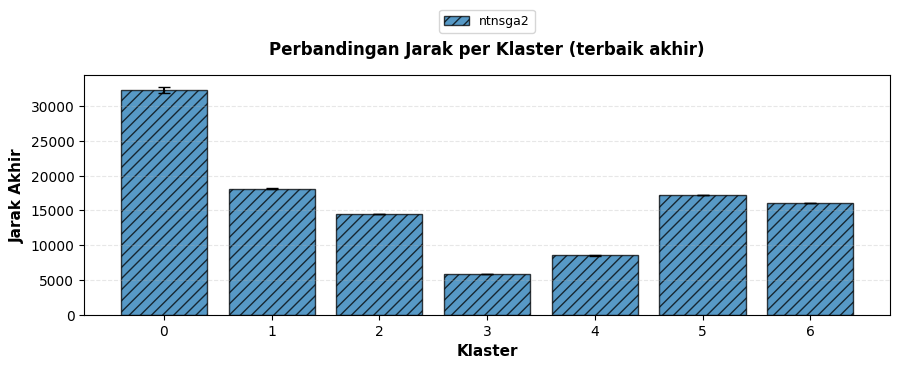

In [15]:
plot_distance_comparison_per_cluster(analyzer, metric="best")


Convergence data prepared for cluster=cluster_0: 1 algorithms
  ntnsga2: ['best', 'mean', 'best_route_time', 'mean_route_time']

=== Tabel Konvergensi cluster_0 - jarak ===
Algoritma best_iter_akhir best_nilai_awal best_nilai_akhir best_std_akhir best_nilai_terbaik best_improvement best_improvement_% mean_iter_akhir mean_nilai_awal mean_nilai_akhir mean_std_akhir mean_nilai_terbaik mean_improvement mean_improvement_%
  ntnsga2          29.000       33753.062        32358.853        427.856          32358.853         1394.209              4.131          29.000       44962.337        32647.746        227.297          32647.746        12314.590             27.389

=== Tabel Best Jarak per Iterasi (cluster_0) ===
 Iterasi   ntnsga2
       1 33753.062
       2 33015.780
       3 32708.415
       4 32621.319
       5 32557.159
       6 32510.986
       7 32490.031
       8 32462.571
       9 32448.753
      10 32448.753
      11 32445.309
      12 32436.484
      13 32436.484
      14 32420

Saved to: figure/testing/convergence_cluster_0_jarak.png


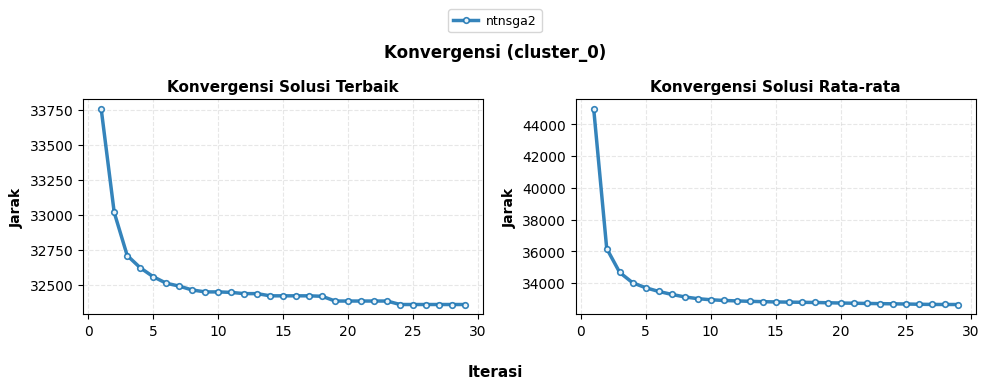


=== Tabel Konvergensi cluster_0 - waktu ===
Algoritma best_route_time_iter_akhir best_route_time_nilai_awal best_route_time_nilai_akhir best_route_time_std_akhir best_route_time_nilai_terbaik best_route_time_improvement best_route_time_improvement_% mean_route_time_iter_akhir mean_route_time_nilai_awal mean_route_time_nilai_akhir mean_route_time_std_akhir mean_route_time_nilai_terbaik mean_route_time_improvement mean_route_time_improvement_%
  ntnsga2                     29.000                  33753.062                   32358.853                   427.856                     32358.853                    1394.209                         4.131                     29.000                  44962.337                   32647.746                   227.297                     32647.746                   12314.590                        27.389
Saved to: figure/testing/convergence_cluster_0_waktu.png


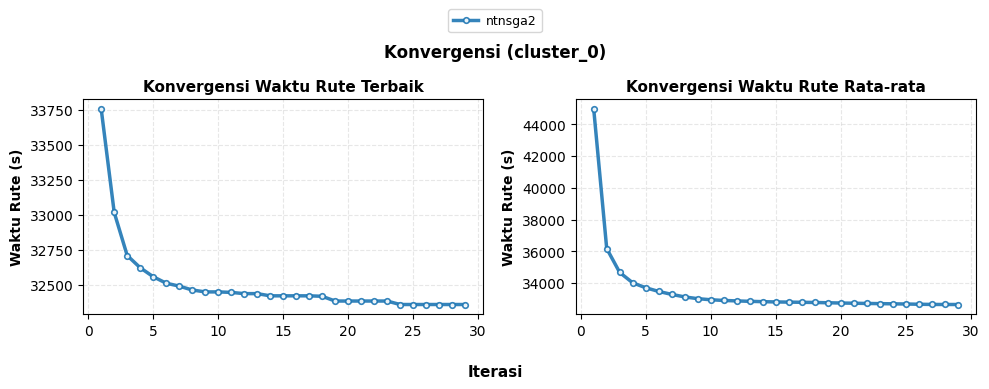


Convergence data prepared for cluster=cluster_1: 1 algorithms
  ntnsga2: ['best', 'mean', 'best_route_time', 'mean_route_time']

=== Tabel Konvergensi cluster_1 - jarak ===
Algoritma best_iter_akhir best_nilai_awal best_nilai_akhir best_std_akhir best_nilai_terbaik best_improvement best_improvement_% mean_iter_akhir mean_nilai_awal mean_nilai_akhir mean_std_akhir mean_nilai_terbaik mean_improvement mean_improvement_%
  ntnsga2          40.000       18187.543        18123.309         41.783          18123.309           64.234              0.353          40.000       25427.860        18123.309         41.783          18123.309         7304.550             28.727

=== Tabel Best Jarak per Iterasi (cluster_1) ===
 Iterasi   ntnsga2
       1 18187.543
       2 18137.237
       3 18123.309
       4 18123.309
       5 18123.309
       6 18123.309
       7 18123.309
       8 18123.309
       9 18123.309
      10 18123.309
      11 18123.309
      12 18123.309
      13 18123.309
      14 18123

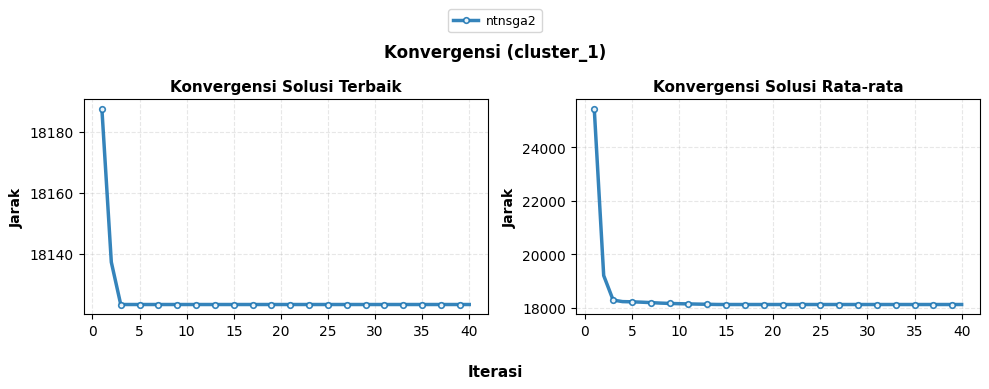


=== Tabel Konvergensi cluster_1 - waktu ===
Algoritma best_route_time_iter_akhir best_route_time_nilai_awal best_route_time_nilai_akhir best_route_time_std_akhir best_route_time_nilai_terbaik best_route_time_improvement best_route_time_improvement_% mean_route_time_iter_akhir mean_route_time_nilai_awal mean_route_time_nilai_akhir mean_route_time_std_akhir mean_route_time_nilai_terbaik mean_route_time_improvement mean_route_time_improvement_%
  ntnsga2                     40.000                  18187.543                   18123.309                    41.783                     18123.309                      64.234                         0.353                     40.000                  25427.860                   18123.309                    41.783                     18123.309                    7304.550                        28.727
Saved to: figure/testing/convergence_cluster_1_waktu.png


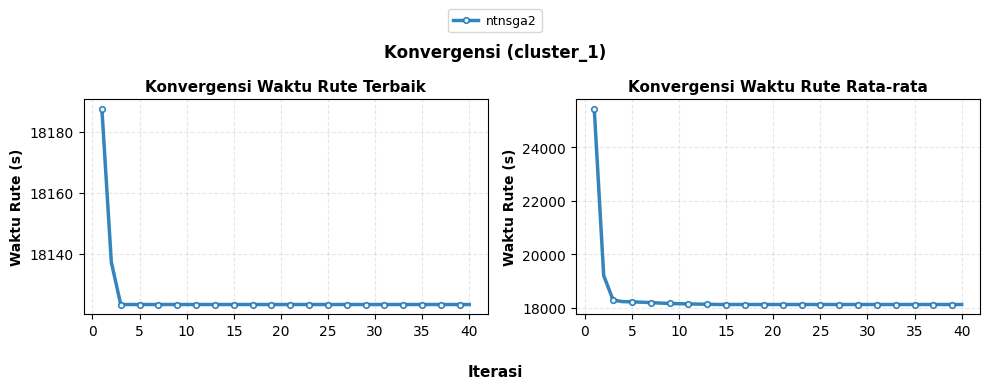


Convergence data prepared for cluster=cluster_2: 1 algorithms
  ntnsga2: ['best', 'mean', 'best_route_time', 'mean_route_time']

=== Tabel Konvergensi cluster_2 - jarak ===
Algoritma best_iter_akhir best_nilai_awal best_nilai_akhir best_std_akhir best_nilai_terbaik best_improvement best_improvement_% mean_iter_akhir mean_nilai_awal mean_nilai_akhir mean_std_akhir mean_nilai_terbaik mean_improvement mean_improvement_%
  ntnsga2          40.000       14520.030        14520.030          0.000          14520.030            0.000              0.000          40.000       21096.287        14520.030          0.000          14520.030         6576.257             31.173

=== Tabel Best Jarak per Iterasi (cluster_2) ===
 Iterasi   ntnsga2
       1 14520.030
       2 14520.030
       3 14520.030
       4 14520.030
       5 14520.030
       6 14520.030
       7 14520.030
       8 14520.030
       9 14520.030
      10 14520.030
      11 14520.030
      12 14520.030
      13 14520.030
      14 14520

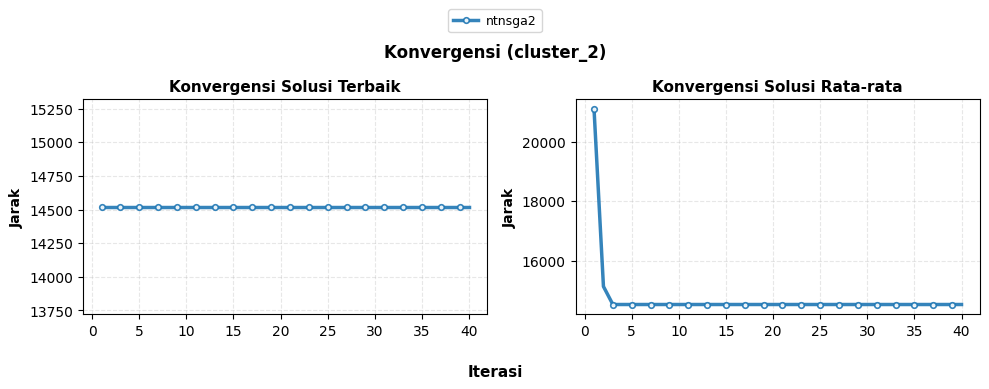


=== Tabel Konvergensi cluster_2 - waktu ===
Algoritma best_route_time_iter_akhir best_route_time_nilai_awal best_route_time_nilai_akhir best_route_time_std_akhir best_route_time_nilai_terbaik best_route_time_improvement best_route_time_improvement_% mean_route_time_iter_akhir mean_route_time_nilai_awal mean_route_time_nilai_akhir mean_route_time_std_akhir mean_route_time_nilai_terbaik mean_route_time_improvement mean_route_time_improvement_%
  ntnsga2                     40.000                  14520.030                   14520.030                     0.000                     14520.030                       0.000                         0.000                     40.000                  21096.287                   14520.030                     0.000                     14520.030                    6576.257                        31.173
Saved to: figure/testing/convergence_cluster_2_waktu.png


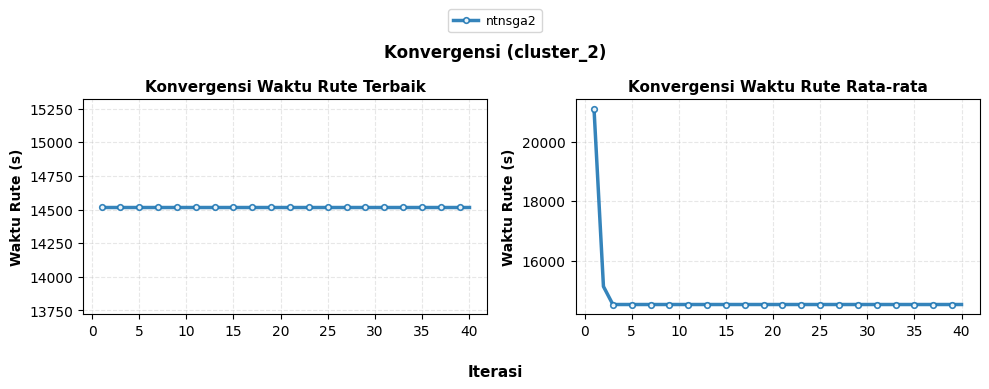


Convergence data prepared for cluster=cluster_3: 1 algorithms
  ntnsga2: ['best', 'mean', 'best_route_time', 'mean_route_time']

=== Tabel Konvergensi cluster_3 - jarak ===
Algoritma best_iter_akhir best_nilai_awal best_nilai_akhir best_std_akhir best_nilai_terbaik best_improvement best_improvement_% mean_iter_akhir mean_nilai_awal mean_nilai_akhir mean_std_akhir mean_nilai_terbaik mean_improvement mean_improvement_%
  ntnsga2          41.000        5818.707         5818.707          0.000           5818.707            0.000              0.000          41.000        6935.846         5818.707          0.000           5818.707         1117.139             16.107

=== Tabel Best Jarak per Iterasi (cluster_3) ===
 Iterasi  ntnsga2
       1 5818.707
       2 5818.707
       3 5818.707
       4 5818.707
       5 5818.707
       6 5818.707
       7 5818.707
       8 5818.707
       9 5818.707
      10 5818.707
      11 5818.707
      12 5818.707
      13 5818.707
      14 5818.707
      15 5

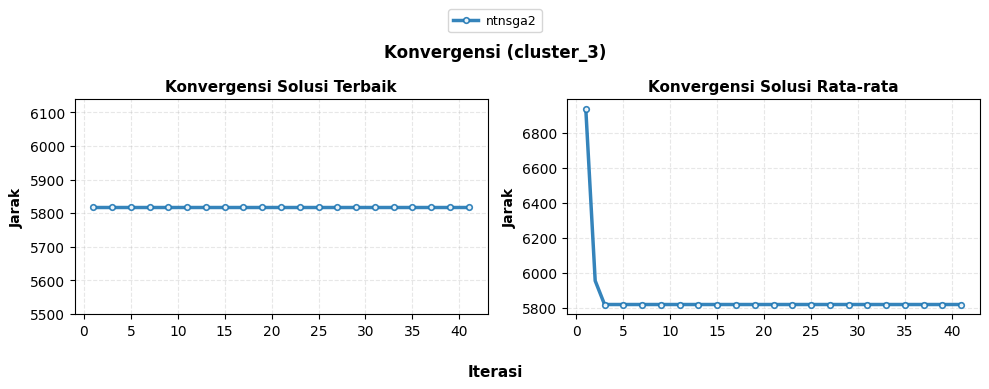


=== Tabel Konvergensi cluster_3 - waktu ===
Algoritma best_route_time_iter_akhir best_route_time_nilai_awal best_route_time_nilai_akhir best_route_time_std_akhir best_route_time_nilai_terbaik best_route_time_improvement best_route_time_improvement_% mean_route_time_iter_akhir mean_route_time_nilai_awal mean_route_time_nilai_akhir mean_route_time_std_akhir mean_route_time_nilai_terbaik mean_route_time_improvement mean_route_time_improvement_%
  ntnsga2                     41.000                   5818.707                    5818.707                     0.000                      5818.707                       0.000                         0.000                     41.000                   6935.846                    5818.707                     0.000                      5818.707                    1117.139                        16.107
Saved to: figure/testing/convergence_cluster_3_waktu.png


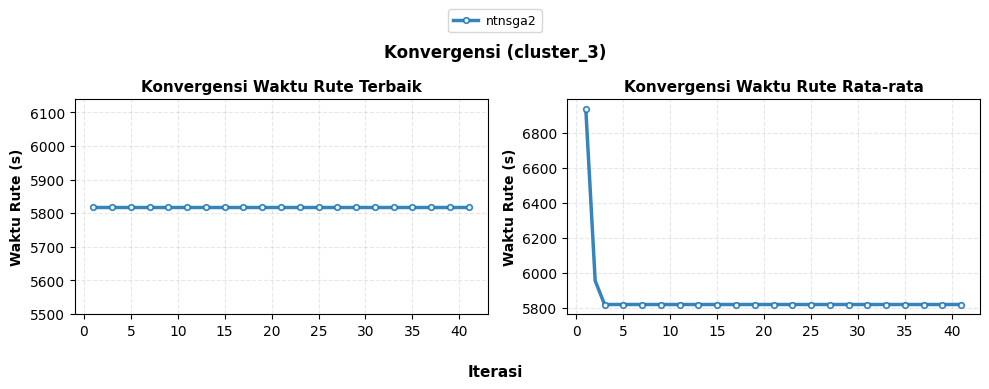


Convergence data prepared for cluster=cluster_4: 1 algorithms
  ntnsga2: ['best', 'mean', 'best_route_time', 'mean_route_time']

=== Tabel Konvergensi cluster_4 - jarak ===
Algoritma best_iter_akhir best_nilai_awal best_nilai_akhir best_std_akhir best_nilai_terbaik best_improvement best_improvement_% mean_iter_akhir mean_nilai_awal mean_nilai_akhir mean_std_akhir mean_nilai_terbaik mean_improvement mean_improvement_%
  ntnsga2          42.000        8567.309         8547.316         78.980           8547.316           19.993              0.233          42.000       10786.889         8547.316         78.980           8547.316         2239.573             20.762

=== Tabel Best Jarak per Iterasi (cluster_4) ===
 Iterasi  ntnsga2
       1 8567.309
       2 8547.316
       3 8547.316
       4 8547.316
       5 8547.316
       6 8547.316
       7 8547.316
       8 8547.316
       9 8547.316
      10 8547.316
      11 8547.316
      12 8547.316
      13 8547.316
      14 8547.316
      15 8

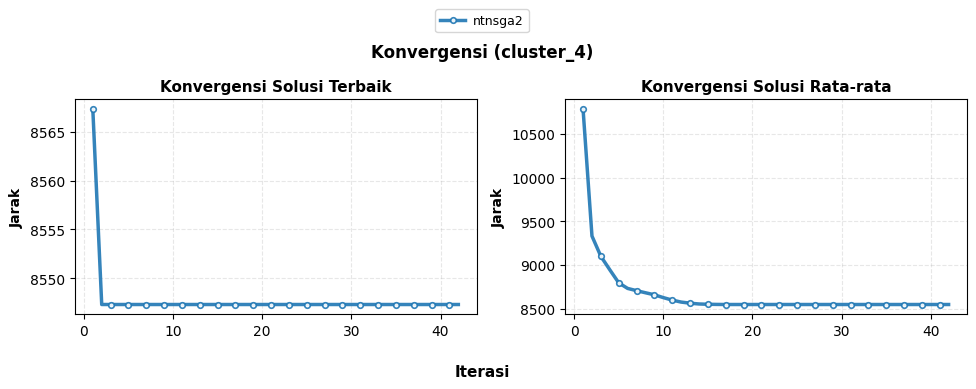


=== Tabel Konvergensi cluster_4 - waktu ===
Algoritma best_route_time_iter_akhir best_route_time_nilai_awal best_route_time_nilai_akhir best_route_time_std_akhir best_route_time_nilai_terbaik best_route_time_improvement best_route_time_improvement_% mean_route_time_iter_akhir mean_route_time_nilai_awal mean_route_time_nilai_akhir mean_route_time_std_akhir mean_route_time_nilai_terbaik mean_route_time_improvement mean_route_time_improvement_%
  ntnsga2                     42.000                   8567.309                    8547.316                    78.980                      8547.316                      19.993                         0.233                     42.000                  10786.889                    8547.316                    78.980                      8547.316                    2239.573                        20.762
Saved to: figure/testing/convergence_cluster_4_waktu.png


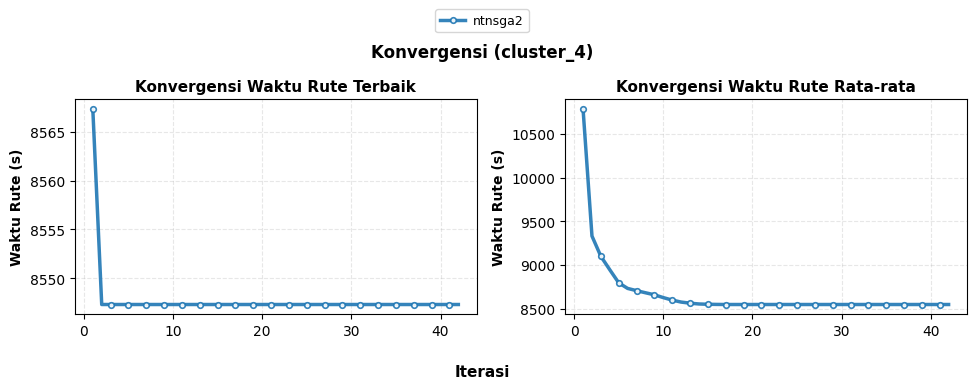


Convergence data prepared for cluster=cluster_5: 1 algorithms
  ntnsga2: ['best', 'mean', 'best_route_time', 'mean_route_time']

=== Tabel Konvergensi cluster_5 - jarak ===
Algoritma best_iter_akhir best_nilai_awal best_nilai_akhir best_std_akhir best_nilai_terbaik best_improvement best_improvement_% mean_iter_akhir mean_nilai_awal mean_nilai_akhir mean_std_akhir mean_nilai_terbaik mean_improvement mean_improvement_%
  ntnsga2          41.000       17195.674        17195.674          0.000          17195.674            0.000              0.000          41.000       19884.045        17195.674          0.000          17195.674         2688.372             13.520

=== Tabel Best Jarak per Iterasi (cluster_5) ===
 Iterasi   ntnsga2
       1 17195.674
       2 17195.674
       3 17195.674
       4 17195.674
       5 17195.674
       6 17195.674
       7 17195.674
       8 17195.674
       9 17195.674
      10 17195.674
      11 17195.674
      12 17195.674
      13 17195.674
      14 17195

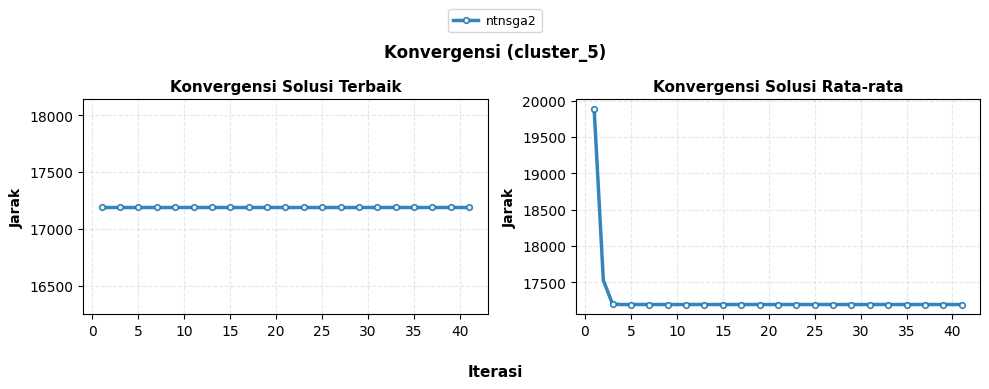


=== Tabel Konvergensi cluster_5 - waktu ===
Algoritma best_route_time_iter_akhir best_route_time_nilai_awal best_route_time_nilai_akhir best_route_time_std_akhir best_route_time_nilai_terbaik best_route_time_improvement best_route_time_improvement_% mean_route_time_iter_akhir mean_route_time_nilai_awal mean_route_time_nilai_akhir mean_route_time_std_akhir mean_route_time_nilai_terbaik mean_route_time_improvement mean_route_time_improvement_%
  ntnsga2                     41.000                  17195.674                   17195.674                     0.000                     17195.674                       0.000                         0.000                     41.000                  19884.045                   17195.674                     0.000                     17195.674                    2688.372                        13.520
Saved to: figure/testing/convergence_cluster_5_waktu.png


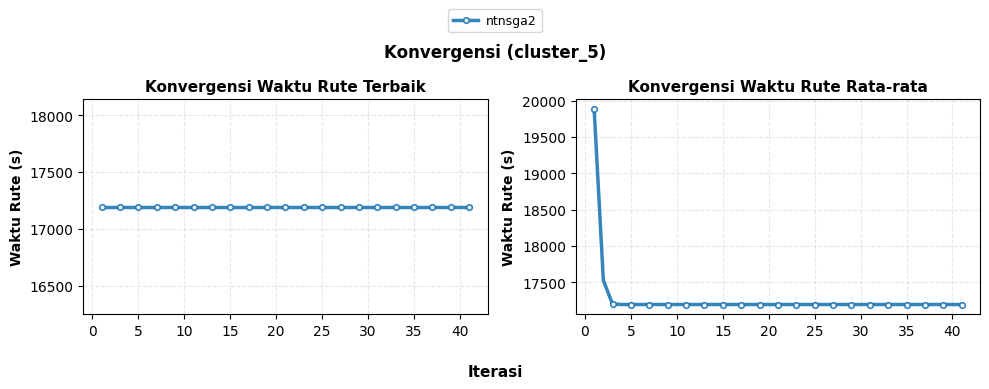


Convergence data prepared for cluster=cluster_6: 1 algorithms
  ntnsga2: ['best', 'mean', 'best_route_time', 'mean_route_time']

=== Tabel Konvergensi cluster_6 - jarak ===
Algoritma best_iter_akhir best_nilai_awal best_nilai_akhir best_std_akhir best_nilai_terbaik best_improvement best_improvement_% mean_iter_akhir mean_nilai_awal mean_nilai_akhir mean_std_akhir mean_nilai_terbaik mean_improvement mean_improvement_%
  ntnsga2          39.000       16116.141        16004.881          0.000          16004.881          111.260              0.690          39.000       19886.647        16009.803         26.509          16009.803         3876.844             19.495

=== Tabel Best Jarak per Iterasi (cluster_6) ===
 Iterasi   ntnsga2
       1 16116.141
       2 16035.590
       3 16018.009
       4 16004.881
       5 16004.881
       6 16004.881
       7 16004.881
       8 16004.881
       9 16004.881
      10 16004.881
      11 16004.881
      12 16004.881
      13 16004.881
      14 16004

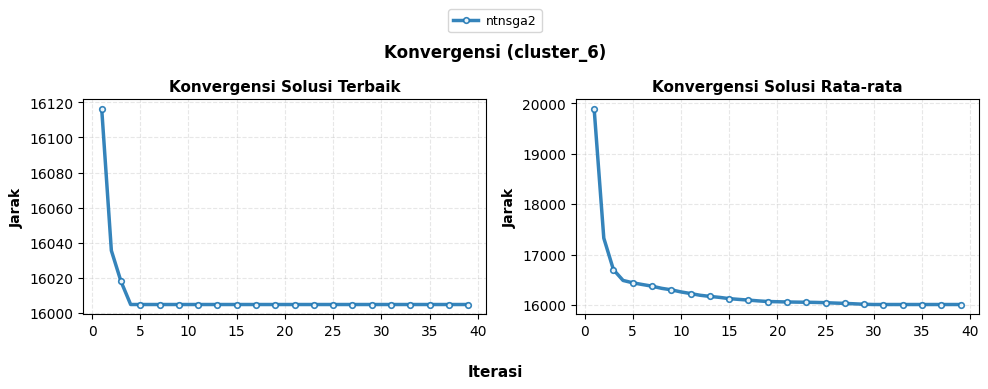


=== Tabel Konvergensi cluster_6 - waktu ===
Algoritma best_route_time_iter_akhir best_route_time_nilai_awal best_route_time_nilai_akhir best_route_time_std_akhir best_route_time_nilai_terbaik best_route_time_improvement best_route_time_improvement_% mean_route_time_iter_akhir mean_route_time_nilai_awal mean_route_time_nilai_akhir mean_route_time_std_akhir mean_route_time_nilai_terbaik mean_route_time_improvement mean_route_time_improvement_%
  ntnsga2                     39.000                  16116.141                   16004.881                     0.000                     16004.881                     111.260                         0.690                     39.000                  19886.647                   16009.803                    26.509                     16009.803                    3876.844                        19.495
Saved to: figure/testing/convergence_cluster_6_waktu.png


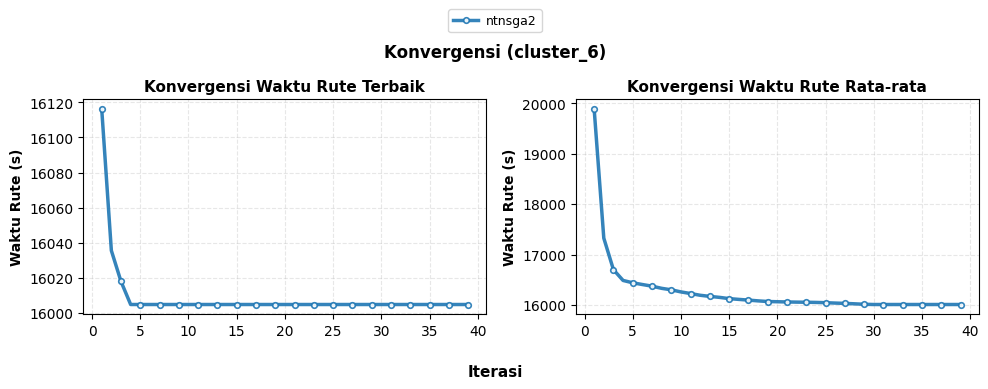

In [16]:
for cluster_name in analyzer.list_clusters():
    conv = get_convergence_data(analyzer, cluster_name)
    plot_convergence_for_cluster(cluster_name, conv)

Saved to: figure/testing/wilcoxon_ntnsga2_vs_azam.png


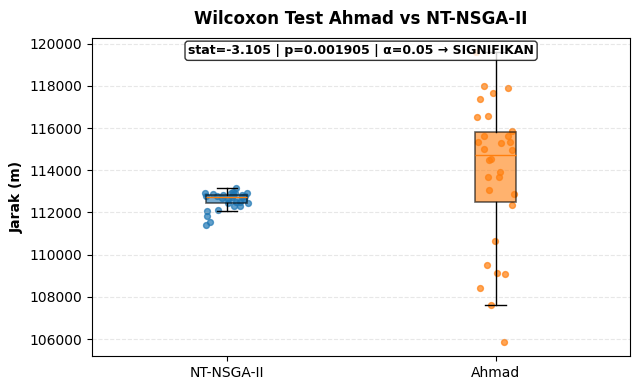


=== Tabel Data Wilcoxon Ahmad vs NT-NSGA-II ===
     n      Ahmad NT-NSGA-II
 1.000 105870.000 111393.349
 2.000 107610.000 111532.626
 3.000 108430.000 111832.762
 4.000 109080.000 112087.010
 5.000 109150.000 112138.146
 6.000 109520.000 112309.317
 7.000 110630.000 112319.853
 8.000 112370.000 112426.304
 9.000 112860.000 112443.840
10.000 113060.000 112482.516
11.000 113660.000 112482.657
12.000 113670.000 112619.988
13.000 113920.000 112646.485
14.000 114480.000 112694.455
15.000 114550.000 112718.359
16.000 114940.000 112736.802
17.000 115000.000 112760.394
18.000 115290.000 112761.204
19.000 115320.000 112783.637
20.000 115340.000 112812.091
21.000 115620.000 112812.539
22.000 115620.000 112812.539
23.000 115870.000 112831.607
24.000 116520.000 112856.009
25.000 116550.000 112901.722
26.000 117400.000 112924.633
27.000 117650.000 112924.633
28.000 117910.000 112924.633
29.000 117990.000 112947.316
30.000 119590.000 113145.665

=== Tabel Statistik Wilcoxon Ahmad vs NT-NSGA-II ==

In [17]:
from scipy.stats import ranksums

AZAM_PATH = Path("results/experiment_azam")

if (not AZAM_PATH.is_file()) and AZAM_PATH.with_suffix(".csv").is_file():
    AZAM_PATH = AZAM_PATH.with_suffix(".csv")


def _pick_ntnsga2_distance_values(global_path: Path, analyzer: ConvergenceAnalyzer):
    """
    Prefer experiment_summary.csv distance values.
    Fallback: use final 'best' from metrics.csv.
    """
    summary_path = global_path / "experiment_summary.csv"

    if summary_path.exists():
        df_sum = pd.read_csv(summary_path)

        if "algorithm" in df_sum.columns and "distance" in df_sum.columns:
            mask = df_sum["algorithm"].astype(str).str.lower().str.contains("ntnsga|nt-nsga")
            vals = pd.to_numeric(
                df_sum.loc[mask, "distance"],
                errors="coerce",
            ).dropna().values

            if len(vals) > 0:
                return vals

    vals = []

    for cluster_name, algos in analyzer.data.items():
        for algo_name, runs in algos.items():
            if re.search(r"ntnsga|nt\-nsga", str(algo_name).lower()):
                for df in runs:
                    if "best" in df.columns and len(df) > 0:
                        v = pd.to_numeric(df["best"].iloc[-1], errors="coerce")

                        if pd.notna(v):
                            vals.append(float(v))

    return np.array(vals, dtype=float)


def plot_wilcoxon_ntnsga2_vs_azam(analyzer: ConvergenceAnalyzer, azam_path: Path):
    if not azam_path.exists():
        print(f"Azam file not found: {azam_path}")
        return

    az = pd.read_csv(azam_path)

    if "jarak" not in az.columns:
        raise KeyError(
            f"Azam CSV missing 'jarak' column. Found columns: {list(az.columns)}"
        )

    az_vals = pd.to_numeric(az["jarak"], errors="coerce").dropna().values.astype(float)
    az_vals = np.sort(az_vals)[:30]

    nt_vals = _pick_ntnsga2_distance_values(GLOBAL_PATH, analyzer)

    if len(nt_vals) < 2 or len(az_vals) < 2:
        print(f"Not enough data. NT-NSGA2 n={len(nt_vals)}, Azam n={len(az_vals)}")
        return

    stat, p = ranksums(nt_vals, az_vals)

    fig, ax = plt.subplots(figsize=(6.5, 4))

    data = [nt_vals, az_vals]
    labels = ["NT-NSGA-II", "Ahmad"]

    bp = ax.boxplot(
        data,
        labels=labels,
        showfliers=False,
        patch_artist=True,
    )

    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for i, b in enumerate(bp["boxes"]):
        b.set_facecolor(colors[i % len(colors)])
        b.set_alpha(0.6)
        b.set_edgecolor("black")
        b.set_linewidth(1.2)

    rng = np.random.default_rng(0)

    for i, vals in enumerate(data, start=1):
        x = i + rng.uniform(-0.08, 0.08, size=len(vals))
        ax.scatter(x, vals, s=18, alpha=0.7)

    ax.set_ylabel("Jarak (m)", fontweight="bold")
    ax.set_title("Wilcoxon Test Ahmad vs NT-NSGA-II", fontweight="bold", pad=10)
    ax.grid(True, axis="y", alpha=0.3, linestyle="--")

    alpha = 0.05
    verdict = "SIGNIFIKAN" if p < alpha else "TIDAK signifikan"

    ax.text(
        0.5,
        0.98,
        f"stat={stat:.3f} | p={p:.4g} | α={alpha} → {verdict}",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=9,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.25",
            fc="white",
            ec="black",
            alpha=0.8,
        ),
    )

    plt.tight_layout()

    save_path = FIG_DIR / "wilcoxon_ntnsga2_vs_azam.png"
    plt.savefig(save_path, bbox_inches="tight", dpi=150)
    print(f"Saved to: {save_path}")
    plt.show()

    az_sorted = np.sort(az_vals)
    nt_sorted = np.sort(nt_vals)

    k = max(len(az_sorted), len(nt_sorted))

    azam_col = np.full(k, np.nan)
    ntnsga_col = np.full(k, np.nan)

    azam_col[:len(az_sorted)] = az_sorted
    ntnsga_col[:len(nt_sorted)] = nt_sorted

    df_table = pd.DataFrame({
        "n": np.arange(1, k + 1),
        "Ahmad": azam_col,
        "NT-NSGA-II": ntnsga_col,
    })

    print_numeric_table(
        "Tabel Data Wilcoxon Ahmad vs NT-NSGA-II",
        df_table,
        digits=3,
    )

    df_summary = pd.DataFrame([
        {
            "Metode": "Ahmad",
            "n": len(az_vals),
            "Mean": float(np.mean(az_vals)),
            "Std": float(np.std(az_vals)),
            "Min": float(np.min(az_vals)),
            "Median": float(np.median(az_vals)),
            "Max": float(np.max(az_vals)),
        },
        {
            "Metode": "NT-NSGA-II",
            "n": len(nt_vals),
            "Mean": float(np.mean(nt_vals)),
            "Std": float(np.std(nt_vals)),
            "Min": float(np.min(nt_vals)),
            "Median": float(np.median(nt_vals)),
            "Max": float(np.max(nt_vals)),
        },
    ])

    print_numeric_table(
        "Tabel Statistik Wilcoxon Ahmad vs NT-NSGA-II",
        df_summary,
        digits=3,
    )

    print(
        f"\nWilcoxon rank-sum: "
        f"stat={stat:.6f}, p-value={p:.6f}, alpha={alpha}, verdict={verdict}"
    )

    df_table.to_csv(FIG_DIR / "table_azam_vs_ntnsga.csv", index=False)


plot_wilcoxon_ntnsga2_vs_azam(analyzer, AZAM_PATH)